# PINN Modeling of viscous Burgers equation with small viscosity

# The Burgers equation reads:

\begin{equation}
 \frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}, \\
\end{equation}

## We will focus at initial condition:

\begin{equation}
u(x,0)= -\sin(\pi x).
\end{equation}

## Environment set up

We train the PINN using PyTorch, using the following environment set up:
```bash

conda create -n pinn python=3
conda activate pinn
conda install jupyter numpy matplotlib
conda install pytorch torchvision torchaudio -c pytorch
```



**Import Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
import os
import sys
from scipy.integrate import odeint

from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch import optim
import progressbar

## We define several visualization functions

In [2]:
def plot_spatio_temp_3D(x,t,z):
    """
    Plot a 2 two parameters function z = f(x,t) where x-axis is spatial and y-axis is time.
    
    (x:np.ndarray (format 1D), y:np.ndarray (format 1D), z:np.ndarray (format 1D)) -> plot
    """
    fig = plt.figure(figsize = (10,9))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlabel('$x \ [\mathrm{m}]$', fontsize = 16)
    ax.set_ylabel('$t \ [\mathrm{s}]$', fontsize = 16)
    ax.set_zlabel('$u \ [\mathrm{m}]$', fontsize = 16)
    ax.view_init(elev = 15, azim = 120)
    
    SX,ST = np.meshgrid(t,x)
    p = ax.plot_surface(ST,SX,z,cmap = plt.cm.viridis)
    plt.show()  

<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\ '
<>:11: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\ '
<>:11: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_13601/2644675906.py:9: SyntaxWarning: invalid escape sequence '\ '
  ax.set_xlabel('$x \ [\mathrm{m}]$', fontsize = 16)
/tmp/ipykernel_13601/2644675906.py:10: SyntaxWarning: invalid escape sequence '\ '
  ax.set_ylabel('$t \ [\mathrm{s}]$', fontsize = 16)
/tmp/ipykernel_13601/2644675906.py:11: SyntaxWarning: invalid escape sequence '\ '
  ax.set_zlabel('$u \ [\mathrm{m}]$', fontsize = 16)


In [3]:
def plot_spatio_temp_flat(x,y,t):
    plt.figure(figsize=(12,4),dpi=100)
    plt.imshow(y, extent=[t[0],t[y.shape[0] - 1],x[0],x[y.shape[1] - 1]])
    cbar = plt.colorbar()
    cbar.set_label('u $[m/s]$')
    plt.ylabel('$x \ [\mathrm{m}]$')
    plt.xlabel('$t \ [\mathrm{s}]$')
    plt.axis(True)
    plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\ '
<>:7: SyntaxWarning: invalid escape sequence '\ '
<>:6: SyntaxWarning: invalid escape sequence '\ '
<>:7: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_13601/1479134368.py:6: SyntaxWarning: invalid escape sequence '\ '
  plt.ylabel('$x \ [\mathrm{m}]$')
/tmp/ipykernel_13601/1479134368.py:7: SyntaxWarning: invalid escape sequence '\ '
  plt.xlabel('$t \ [\mathrm{s}]$')


In [4]:
def plot_sequence(x,y):
    fig = plt.figure(figsize = (8,7))
    ax = fig.add_subplot(111)
    ax.set_xlabel('$x$ [$\mathrm{m}$]')
    ax.set_ylabel('$u(x,t)$')
    y_plot = y[0:-1:20,:]
    for j in range(y_plot.shape[0]):
        ax.plot(x, y_plot[j,:], color = plt.cm.brg(20*j))
    
    plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_13601/1775891872.py:4: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('$x$ [$\mathrm{m}$]')


In [5]:

def plot_PINN(train_data,N_x,N_t,model):
    x_t = train_data.detach().numpy()
    for i in range(N_x):
        print(x_t[i,:])
    x = x_t[::N_x,:1].reshape(1,-1)[0]
    t = x_t[:N_t,1:2].reshape(1,-1)[0]
    u = model(train_data).detach().numpy().reshape(N_x,-1)
    plot_spatio_temp_3D(x,t,u)
    plot_spatio_temp_flat(x,u,t)
    plot_sequence(x,u.T)

## We numerically solve viscous Burgers for a given initial condition and plot some figures

In [6]:
############## SET-UP THE PROBLEM ###############
nu = 0.01 #kinematic viscosity coefficient
    
#Spatial mesh
L_x = 2 #Range of the domain according to x [m]
dx = 0.02 #Infinitesimal distance
N_x = int(L_x/dx) #Points number of the spatial mesh
# The domain of study depends on the initial condition we want to study
#X = np.linspace(0,L_x,N_x) #Spatial array for the case u0 exponential
X = np.linspace(-L_x/2,L_x/2,N_x) #Spatial array for the case u0 sinusoidal
x_min,x_max = -L_x/2,L_x/2

#Temporal mesh
L_t = 1 #Duration of simulation [s]
dt = 0.01  #Infinitesimal time
N_t = int(L_t/dt) #Points number of the temporal mesh
T = np.linspace(0,L_t,N_t) #Temporal array
t_min,t_max = 0.,L_t

# We will solve Burgers in Fourier domain since spatial derivatives become products and so PDEs become ODEs
#Wave number discretization
k = 2*np.pi*np.fft.fftfreq(N_x, d = dx)

#Def of the initial condition    
#u0 = np.exp(-(X-3)**2/2) #Single space variable fonction that represent the wave form at t = 0
u0 = -np.sin(np.pi * X) #Single space variable fonction that represent the wave form at t = 0

############## EQUATION SOLVING ###############

#Definition of ODE system (PDE ---(FFT)---> ODE system)
def burg_system(u,t,k,nu):
    #Spatial derivative in the Fourier domain
    u_hat = np.fft.fft(u)
    u_hat_x = 1j*k*u_hat
    u_hat_xx = -k**2*u_hat
    
    #Switching in the spatial domain
    u_x = np.fft.ifft(u_hat_x)
    u_xx = np.fft.ifft(u_hat_xx)
    
    #ODE resolution
    u_t = -u*u_x + nu*u_xx
    return u_t.real
    

#PDE resolution (ODE system resolution)
U = odeint(burg_system, u0, T, args=(k,nu,), mxstep=5000).T

**Plots**

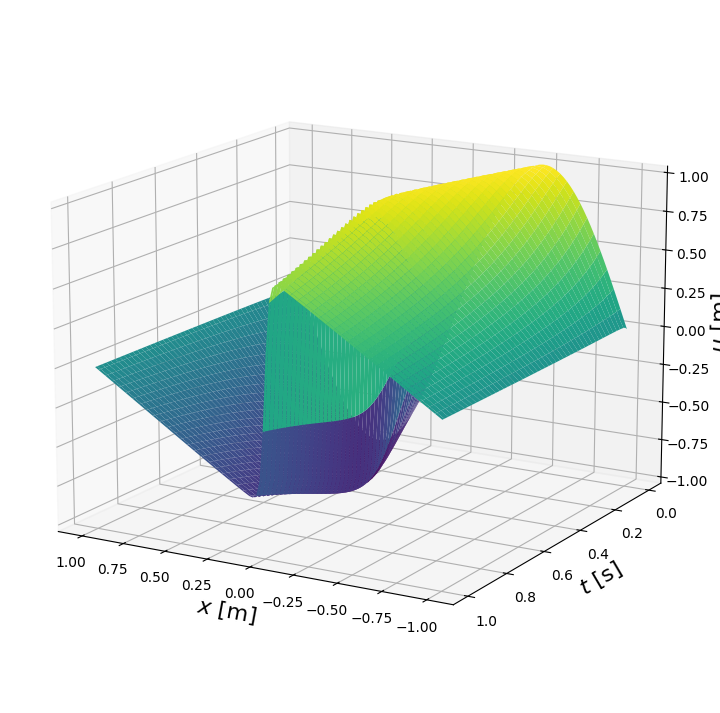

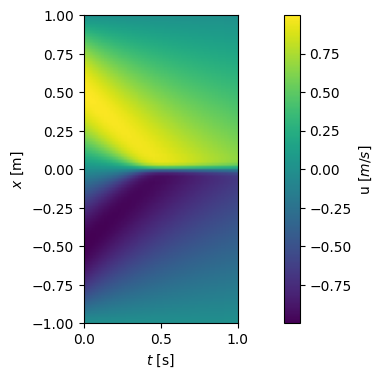

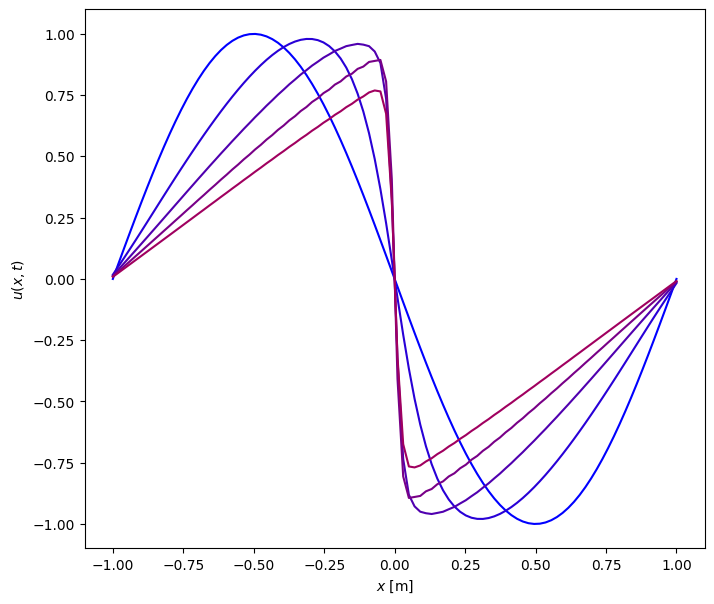

In [7]:
############## PLOT ###############
plot_spatio_temp_3D(X,T,U)

plot_spatio_temp_flat(X,U,T)

plot_sequence(X,U.T)

# NN model

In [8]:
class Burger_PINN(nn.Module):

    def __init__(self,n_input,n_output,n_hidden,n_layers):
        super().__init__()

        activation = nn.Tanh
        self.input_layer = nn.Sequential(*[
                                    nn.Linear(n_input, n_hidden),
                                    activation()])

        self.hidden_layers = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(n_hidden, n_hidden),
                            activation()]) for _ in range(n_layers-1)])

        self.output_layer = nn.Linear(n_hidden, n_output)

    def forward(self,x):

        x=self.input_layer(x)
        x=self.hidden_layers(x)
        x=self.output_layer(x)

        return x

In [9]:
torch.manual_seed(119)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Burger_PINN(n_input=2,n_output=1,n_hidden=20,n_layers=8)

# Definition of initial conditions, boundary conditions and full space-time grid

**Initial Conditions**

In [10]:
nbr_initial_x = N_x   # N_x samples in space for the definition of the initial condition
nbr_initial_t = 1     # Only t=0 for defining the initial condition

In [11]:
def initial_conditions(x_initial,t_initial):
    return -np.sin(np.pi*x_initial)

In [12]:
class initials_variables_data(torch.utils.data.Dataset):
    def __init__(self,nbr_initial_x,nbr_initial_t):
        #initialise the variables
        self.x_initial = np.linspace(x_min,x_max,nbr_initial_x,dtype="float32")
        self.t_initial = np.array([0 for _ in range (nbr_initial_t)],dtype="float32")  # 0 since the initial condition is defined for t=0

    def __len__(self):
        #return the lenght of the dataset
        return nbr_initial_x * nbr_initial_t

    def __getitem__(self,idx):
        # return the element in that index
        inintial_value = torch.tensor(initial_conditions(self.x_initial,self.t_initial)[idx])

        return self.x_initial[idx],self.t_initial[idx],inintial_value

In [13]:
initial_train_dataset = initials_variables_data(nbr_initial_x,nbr_initial_x)

**Boundary Conditions**

In [14]:
boundary_x = 2    # Boundary conditions of a 1d solution
boundary_t = N_t  # Boundary conditions for any time

In [15]:
# Dirichlet boundary condition
def boundary_conditions(x_boundary,t_boundary):
    u_boundary = 0
    return u_boundary

In [16]:
# We impose dirichlet with u=0 at the boundaries
class boundary_variables_data(torch.utils.data.Dataset):
    def __init__(self,boundary_x,boundary_t):
        #initialise the variables
        self.boundary_x = boundary_x
        self.boundary_t = boundary_t

        self.x_boundary = np.linspace(x_min,x_max,self.boundary_x,dtype="float32")
        self.t_boundary = np.linspace(t_min,t_max,self.boundary_t,dtype="float32")

    def __len__(self):
        #return the lenght of the dataset
        return boundary_x*boundary_t

    def __getitem__(self,idx):
        # return the element in that index
        j = (idx)//self.boundary_t
        i = idx%self.boundary_t
        boundary_value = torch.tensor(boundary_conditions(self.x_boundary[j],self.t_boundary[i]))

        return self.x_boundary[j],self.t_boundary[i],boundary_value


In [17]:
boundary_train_dataset = boundary_variables_data(boundary_x,boundary_t)

**Full Grid**

In [18]:
class variables_data(torch.utils.data.Dataset):
    def __init__(self,N_x,N_t):
        #initialise the variables
        self.x = np.linspace(x_min,x_max,N_x,dtype="float32")
        self.t = np.linspace(t_min,t_max,N_t,dtype="float32")

    def __len__(self):
        #return the lenght of the dataset
        return N_x*N_t

    def __getitem__(self,idx):
        # return the element in that index
        j = (idx)//N_x
        i = idx%N_t
        return self.x[j],self.t[i]  # This class only returns the x and t values of the grid not the velocity

In [19]:
train_dataset = variables_data(N_x,N_t)

# Training the Model

In [20]:
class Train_PINN():

    def __init__(self,learning_rate,nbr_iteration,w_1,w_2,w_3):
        self.learning_rate = learning_rate
        self.nbr_iteration = nbr_iteration
        self.w_1 = w_1
        self.w_2 = w_2
        self.w_3 = w_3
        self.optimizer = torch.optim.Adam(model.parameters(),lr = self.learning_rate)
        
    def train(self):
        loss = np.zeros((nbr_iteration,1))
        for iteration in range(self.nbr_iteration):
            self.optimizer.zero_grad()

            #initial conditions Loss
            initial_train_data = torch.tensor(initial_train_dataset)
            kecece = initial_train_data[:, 0:2]
            u_pd_ini = model(initial_train_data[:, 0:2])
            u_exa_ini = initial_train_data[:,2:3]
            loss_initital_conditions = self.w_1*torch.mean((u_pd_ini-u_exa_ini)**2)

            #Boundary conditions Loss
            boundary_train_data = torch.tensor(boundary_train_dataset)
            u_pd_bou = model(boundary_train_data[:, 0:2])
            u_exa_bou = boundary_train_data[:,2:3]
            loss_boundary_conditions = self.w_2*torch.mean((u_pd_bou-u_exa_bou)**2)

            #Physical Loss
            train_data = torch.tensor(train_dataset).requires_grad_(True)
            u_pd = model(train_data)
            a = torch.autograd.grad(u_pd, train_data, torch.ones_like(u_pd), create_graph=True)
            u_t = torch.autograd.grad(u_pd, train_data, torch.ones_like(u_pd), create_graph=True)[0][:,1:2]
            u_x = torch.autograd.grad(u_pd, train_data, torch.ones_like(u_pd), create_graph=True)[0][:,0:1]
            u_xx = torch.autograd.grad(u_x, train_data, torch.ones_like(u_pd), create_graph=True)[0][:,0:1]
            physics = u_t + u_pd*u_x - nu*u_xx
            loss_physics = self.w_3*torch.mean(physics**2)

            #Total Loss
            total_loss = loss_initital_conditions + loss_boundary_conditions + loss_physics
            total_loss.backward()
            self.optimizer.step()
            loss[iteration]=total_loss.detach().numpy()
            
        return loss

[-1.  0.]
[-1.          0.01010101]
[-1.          0.02020202]
[-1.          0.03030303]
[-1.          0.04040404]
[-1.          0.05050505]
[-1.          0.06060606]
[-1.          0.07070707]
[-1.          0.08080808]
[-1.          0.09090909]
[-1.         0.1010101]
[-1.          0.11111111]
[-1.          0.12121212]
[-1.          0.13131313]
[-1.          0.14141414]
[-1.          0.15151516]
[-1.          0.16161616]
[-1.          0.17171717]
[-1.          0.18181819]
[-1.         0.1919192]
[-1.         0.2020202]
[-1.          0.21212122]
[-1.          0.22222222]
[-1.          0.23232323]
[-1.          0.24242425]
[-1.          0.25252524]
[-1.          0.26262626]
[-1.          0.27272728]
[-1.          0.28282827]
[-1.         0.2929293]
[-1.         0.3030303]
[-1.         0.3131313]
[-1.          0.32323232]
[-1.          0.33333334]
[-1.          0.34343433]
[-1.          0.35353535]
[-1.          0.36363637]
[-1.          0.37373737]
[-1.         0.3838384]
[-1.         0.3

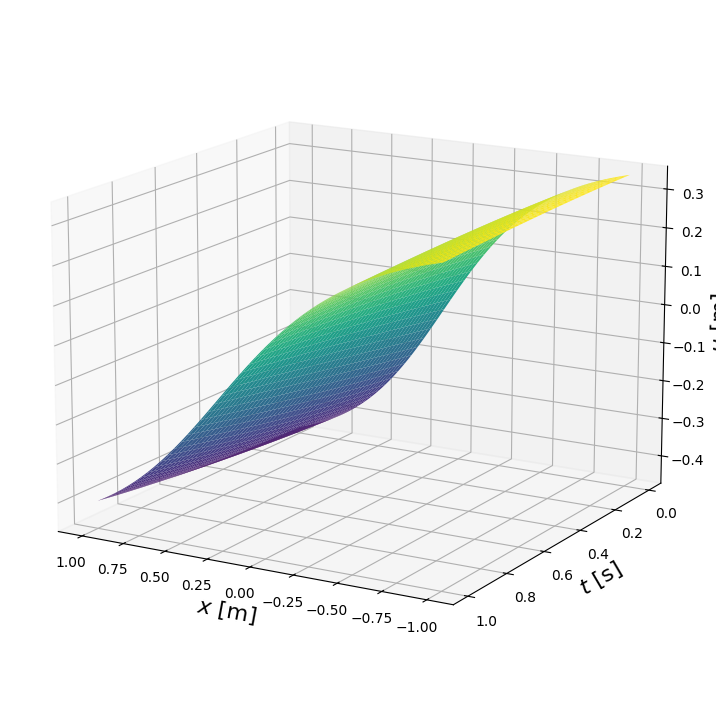

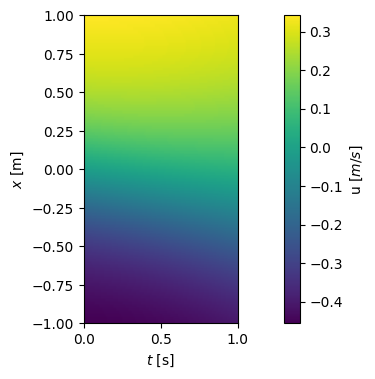

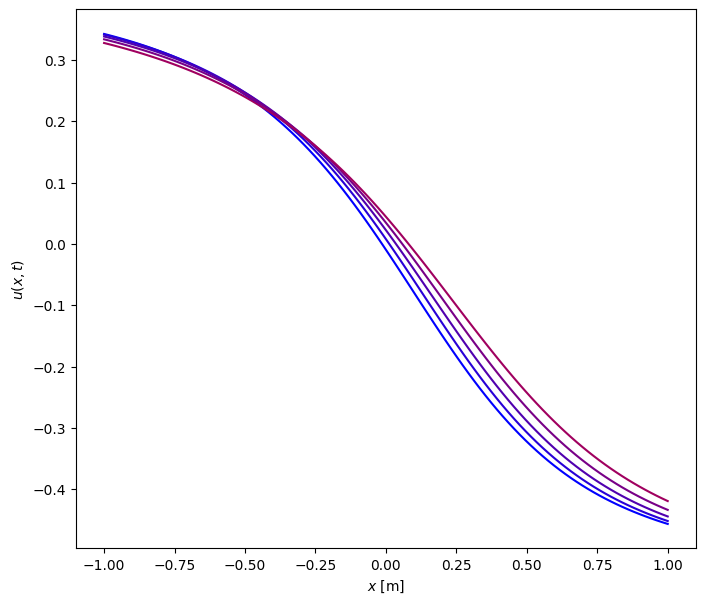

In [21]:
learning_rate,nbr_iteration,w_1,w_2,w3 = 0.005,10,1,1,1
t = Train_PINN(learning_rate,nbr_iteration,w_1,w_2,w3)
Total_loss = t.train()
train_data = torch.tensor(train_dataset)
plot_PINN(train_data,N_x,N_t,model)

# Evaluation of performance

Question 1: Plot the loss function and comment its evolution.

Text(0, 0.5, 'Total loss')

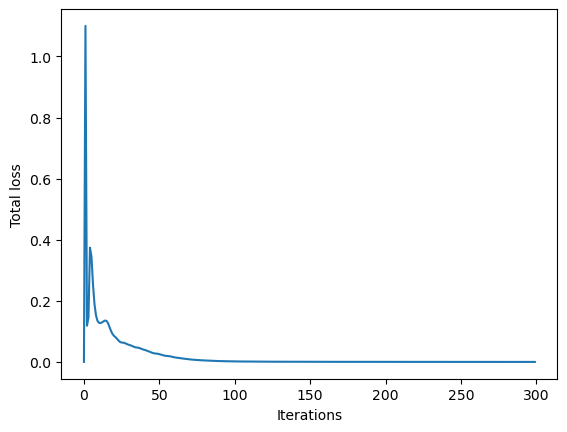

In [38]:
plt.figure()
plt.plot(Total_loss)
plt.xlabel('Iterations')
plt.ylabel('Total loss')

Question 2: Print the value of the Root Mean Square Error. Plot the Mean Square Error and the Absolute Error in function of space and time and comment them.

In [39]:
squareE=(U-model(train_data).detach().numpy().reshape(N_x,-1))**2
print('RMSE between spectral solver and NN solver', np.sqrt(np.mean(squareE)))

RMSE between spectral solver and NN solver 0.010767272830161283


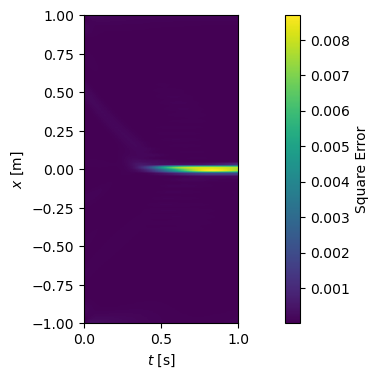

In [40]:
plt.figure(figsize=(12,4),dpi=100)
plt.imshow(squareE, extent=[t_min,t_max,x_min,x_max])
cbar = plt.colorbar()
cbar.set_label('Square Error')
plt.ylabel('$x \ [\mathrm{m}]$')
plt.xlabel('$t \ [\mathrm{s}]$')
plt.axis(True)
plt.show()

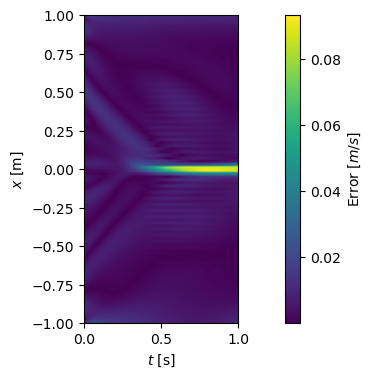

In [41]:
plt.figure(figsize=(12,4),dpi=100)
plt.imshow(np.sqrt(squareE), extent=[t_min,t_max,x_min,x_max])
cbar = plt.colorbar()
cbar.set_label('Error $[m/s]$')
plt.ylabel('$x \ [\mathrm{m}]$')
plt.xlabel('$t \ [\mathrm{s}]$')
plt.axis(True)
plt.show()